In [1]:
import numpy as np

m = 300
X = 6 * np.random.rand(m, 1) - 3
y = 0.8 * X ** 2 + 2 * X + 2 + np.random.randn(m, 1)

In [2]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0], X_poly[0]

(array([1.38638283]), array([1.38638283, 1.92205736]))

In [3]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


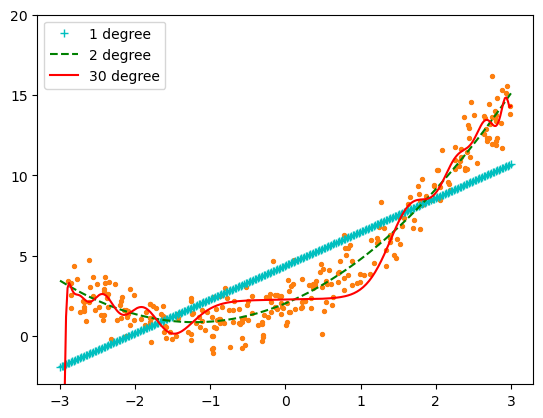

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X, y, 5)

X_new = np.linspace(-3, 3, m).reshape(m, 1)

lin_reg_normal = LinearRegression()
lin_reg_normal.fit(X, y)
y_new = lin_reg_normal.predict(X_new)

plt.plot(X_new, y_new, 'c+', label="1 degree")

X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.plot(X_new, y_new, 'g--', label="2 degree")

poly_features = PolynomialFeatures(degree=30, include_bias=False)
X_poly = poly_features.fit_transform(X)
lin_reg.fit(X_poly, y)

X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.scatter(X, y, 8)
plt.plot(X_new, y_new, 'r-', label="30 degree")
plt.ylim(-3, 20)
plt.legend()

plt.show()